In [54]:
from utils import *
from utils.slugify import slugify

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as plticker
import seaborn as sns
from datetime import date

import pandas as pd
import re
%matplotlib inline

In [2]:
# get total before (before_ocean_online + ocean_online_first_year)
sql = r"""
SELECT DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') as data, COUNT(*) as quantidade
FROM student s, samsungstudents
WHERE s.stu_id=samsungstudents.sam_stu_id
AND DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') BETWEEN '1970-04-22' AND '2021-04-22'
"""

db_con = OceanDB()
df = pd.read_sql(sql, db_con.mydb)
total_before = df['quantidade'].iloc[0]

#get new students from end of April and August 2021
db_con = OceanDB()
cursor = db_con.getCursor()


cursor.execute(r"""
SELECT DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') as data, COUNT(*) as quantidade
FROM student s, samsungstudents
WHERE s.stu_id=samsungstudents.sam_stu_id
AND DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') BETWEEN '2021-04-23' AND '2021-12-31'
GROUP BY DAY(samsungstudents.created_at), MONTH(samsungstudents.created_at), YEAR(samsungstudents.created_at) 
ORDER BY data
""")

result = cursor.fetchall()

dates = []
quantities = []

for x in result:
  dates.append(x[0])
  quantities.append(x[1])

print(len(dates))
print(quantities)


acumulated = np.cumsum(quantities)+total_before
acumulated.shape

251
[8, 13, 7, 15, 27, 43, 10, 25, 15, 67, 90, 88, 43, 40, 27, 6, 18, 35, 24, 32, 34, 17, 18, 22, 12, 19, 24, 26, 13, 10, 12, 12, 12, 21, 32, 27, 20, 60, 87, 104, 374, 331, 245, 75, 96, 486, 366, 204, 109, 65, 25, 22, 38, 68, 35, 25, 9, 14, 12, 22, 9, 13, 8, 19, 41, 45, 59, 284, 248, 221, 149, 110, 75, 96, 48, 39, 27, 42, 33, 28, 36, 35, 34, 39, 15, 6, 11, 16, 18, 18, 14, 6, 15, 16, 11, 7, 19, 31, 60, 21, 28, 38, 47, 30, 30, 151, 80, 38, 104, 82, 45, 39, 22, 20, 12, 34, 23, 22, 21, 18, 37, 15, 28, 32, 14, 67, 64, 62, 38, 54, 42, 72, 44, 38, 31, 16, 23, 39, 42, 41, 32, 25, 21, 20, 11, 37, 22, 15, 11, 2, 7, 27, 18, 30, 9, 10, 3, 9, 34, 21, 41, 107, 63, 43, 87, 71, 53, 31, 13, 9, 9, 17, 14, 26, 42, 18, 12, 13, 21, 40, 15, 11, 29, 11, 8, 29, 29, 24, 56, 71, 69, 46, 38, 55, 59, 39, 67, 240, 438, 162, 65, 63, 22, 38, 9, 12, 11, 12, 12, 26, 22, 18, 10, 25, 30, 20, 26, 90, 30, 14, 55, 8, 12, 11, 13, 8, 6, 12, 27, 16, 6, 13, 1, 2, 17, 34, 20, 6, 2, 2, 2, 3, 10, 3, 3, 1, 7, 4, 13, 5, 2]


(251,)

In [3]:
time_window = 30 # dias
media_movel = np.insert(moving_average(quantities, time_window), [0]*(time_window-1), 0, axis=0)

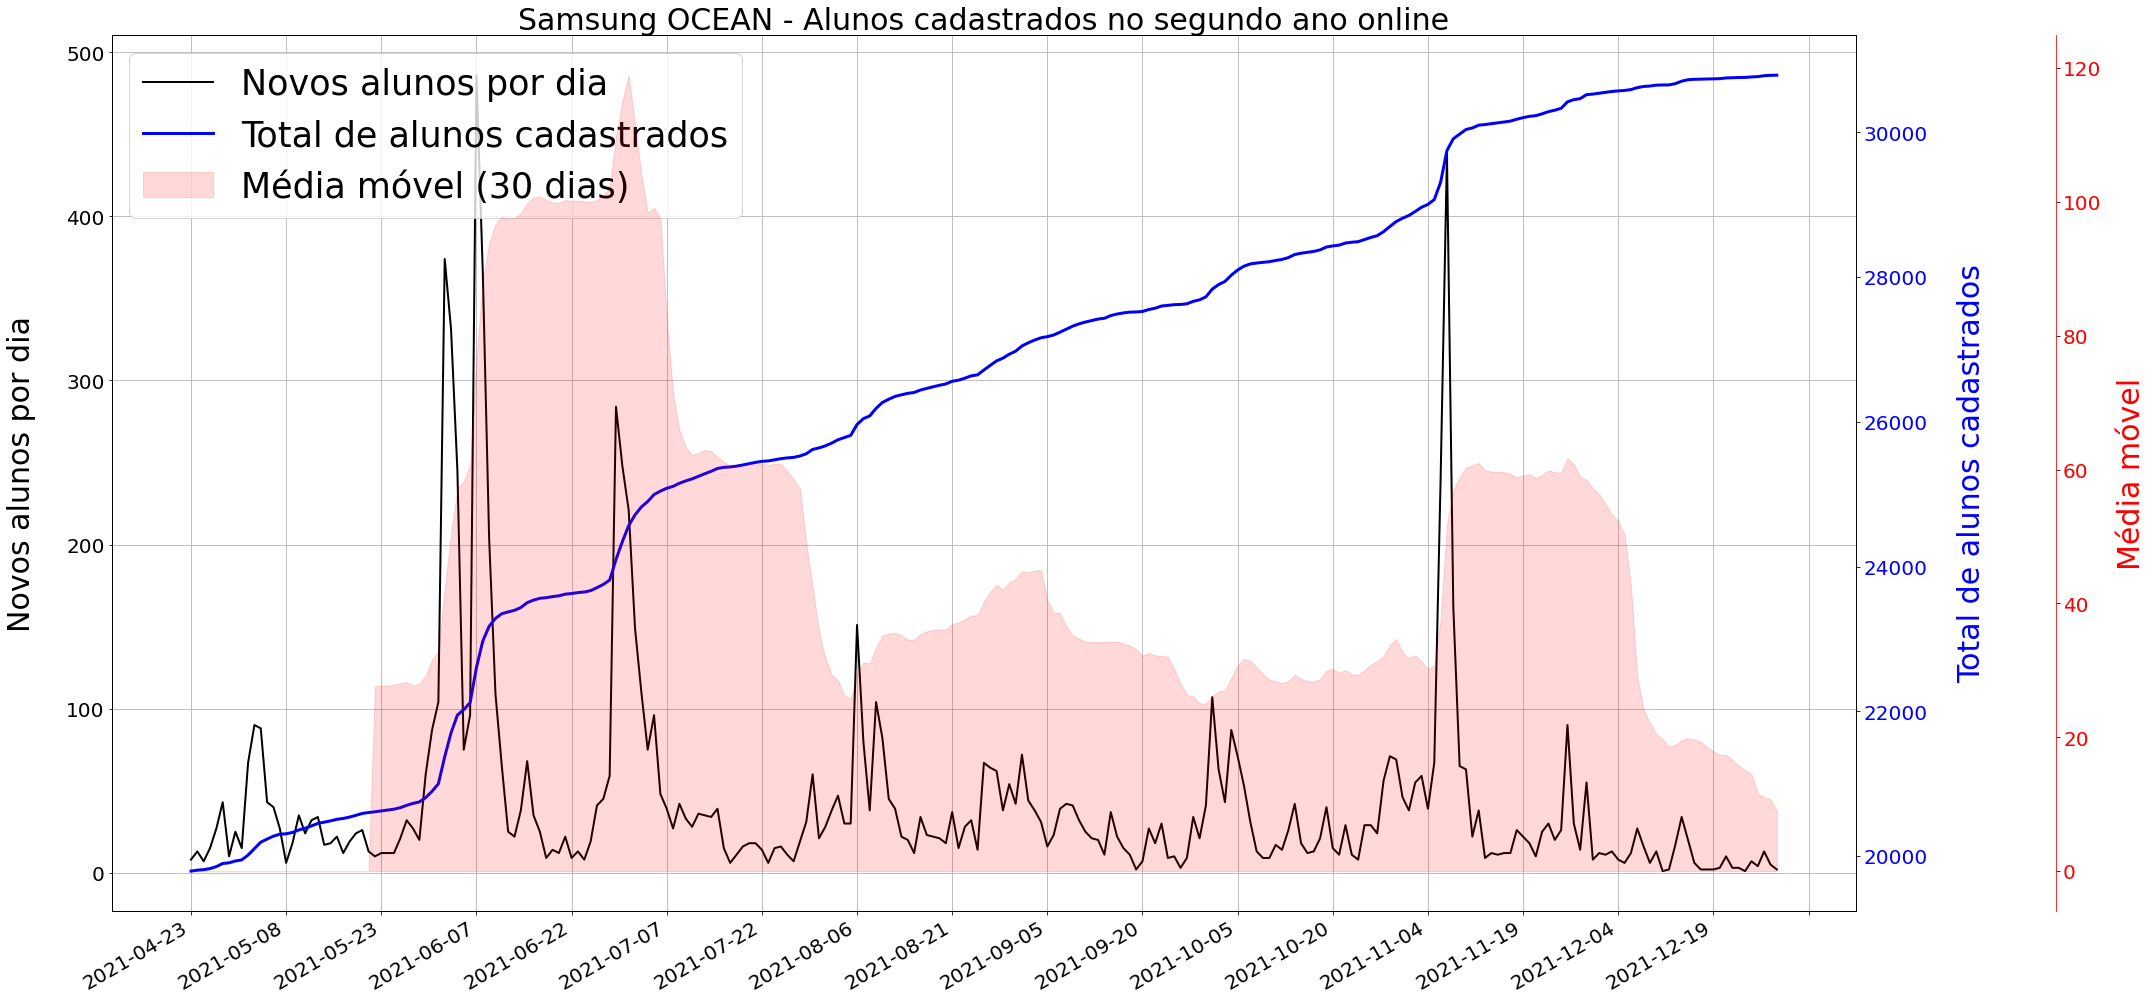

In [4]:
fig, ax = plt.subplots(figsize=(15*2, 7*2))
plot_per_day, = ax.plot(dates, quantities, color='black', marker='', linestyle='solid',linewidth=2, markersize=1, label='Novos alunos por dia');

ax.set_title('Samsung OCEAN - Alunos cadastrados no segundo ano online', fontsize=30)

plt.grid()
ax.set_ylabel('Novos alunos por dia', fontsize=30)
# ax.set_xlim(xmin=yrs[0], xmax=yrs[-1])

# X_TICKS = 20 # use every nth value; change this number until you like the result
# plt.xticks(range(0, len(dates), X_TICKS), dates[::X_TICKS], rotation = 70)

ax2 = ax.twinx()  # instantiate a second axes that shares the same x-axis
plot_accum, = ax2.plot(dates, acumulated, color='blue', marker='', linestyle='solid',linewidth=3, markersize=1, label='Total de alunos cadastrados');

loc = plticker.MultipleLocator(base=15.0) # this locator puts ticks at regular intervals
ax2.xaxis.set_major_locator(loc)
ax2.set_ylabel('Total de alunos cadastrados', fontsize=30, color='blue')


# ax.tick_params(axis='both', which='minor', labelsize=207)

# ax.legend(loc='upper right', fontsize=35)
# ax2.legend(loc='upper left', fontsize=35)


ax.tick_params(labelsize=20)
ax2.tick_params(labelsize=20, labelcolor = "blue")

ax.yaxis.labelpad = 30
ax2.yaxis.labelpad = 30

ax3 = ax.twinx()  # instantiate a third axes that shares the same x-axis
plot_moving_mean = ax3.fill_between(dates, media_movel, color='red', label=f'Média móvel ({time_window} dias)');
plot_moving_mean.set_alpha(0.15)
ax3.xaxis.set_major_locator(loc)
ax3.set_ylabel('Média móvel', fontsize=30, color='red')
ax3.tick_params(labelsize=20, labelcolor = "red")
ax3.yaxis.labelpad = 15
ax3.spines['right'].set_position(('outward', 200))
ax3.spines['right'].set_color('red')
# plt.fill_between(x, y)



lns = [plot_per_day, plot_accum]
labs = [l.get_label() for l in lns]
labs.append(plot_moving_mean.get_label())
# print(labs)
ax.legend([plot_per_day, plot_accum, plot_moving_mean], labs, loc='upper left', fontsize=35)


fig.autofmt_xdate()
fig.tight_layout()

In [5]:
df_qtde_cadastros = pd.DataFrame(data={"Data":dates,"Quantidade":quantities})
df_qtde_cadastros.sort_values(ascending=False,by="Quantidade",ignore_index=True)[:10]

,Data,Quantidade
0,2021-06-07,486
1,2021-11-07,438
2,2021-06-02,374
3,2021-06-08,366
4,2021-06-03,331
5,2021-06-29,284
6,2021-06-30,248
7,2021-06-04,245
8,2021-11-06,240
9,2021-07-01,221


In [6]:
#mudando os dados de YYYY-mm-dd para dd-mm-YYYY
new_data_cadastros = [date.fromisoformat(d) for d in df_qtde_cadastros.Data]
new_data_cadastros = [f"{d.day}/{d.month}/{d.year}"for d in new_data_cadastros]
new_data_cadastros

['23/4/2021',
 '24/4/2021',
 '25/4/2021',
 '26/4/2021',
 '27/4/2021',
 '28/4/2021',
 '29/4/2021',
 '30/4/2021',
 '1/5/2021',
 '2/5/2021',
 '3/5/2021',
 '4/5/2021',
 '5/5/2021',
 '6/5/2021',
 '7/5/2021',
 '8/5/2021',
 '9/5/2021',
 '10/5/2021',
 '11/5/2021',
 '12/5/2021',
 '13/5/2021',
 '14/5/2021',
 '15/5/2021',
 '16/5/2021',
 '17/5/2021',
 '18/5/2021',
 '19/5/2021',
 '20/5/2021',
 '21/5/2021',
 '22/5/2021',
 '23/5/2021',
 '24/5/2021',
 '25/5/2021',
 '26/5/2021',
 '27/5/2021',
 '28/5/2021',
 '29/5/2021',
 '30/5/2021',
 '31/5/2021',
 '1/6/2021',
 '2/6/2021',
 '3/6/2021',
 '4/6/2021',
 '5/6/2021',
 '6/6/2021',
 '7/6/2021',
 '8/6/2021',
 '9/6/2021',
 '10/6/2021',
 '11/6/2021',
 '12/6/2021',
 '13/6/2021',
 '14/6/2021',
 '15/6/2021',
 '16/6/2021',
 '17/6/2021',
 '18/6/2021',
 '19/6/2021',
 '20/6/2021',
 '21/6/2021',
 '22/6/2021',
 '23/6/2021',
 '24/6/2021',
 '25/6/2021',
 '26/6/2021',
 '27/6/2021',
 '28/6/2021',
 '29/6/2021',
 '30/6/2021',
 '1/7/2021',
 '2/7/2021',
 '3/7/2021',
 '4/7/2021',


In [7]:
df_qtde_cadastros2 = pd.DataFrame(data={"Data":new_data_cadastros,"Quantidade":df_qtde_cadastros.Quantidade}).sort_values(by="Quantidade",ascending=False,ignore_index=True)
df_qtde_cadastros2.head(10)

,Data,Quantidade
0,7/6/2021,486
1,7/11/2021,438
2,2/6/2021,374
3,8/6/2021,366
4,3/6/2021,331
5,29/6/2021,284
6,30/6/2021,248
7,4/6/2021,245
8,6/11/2021,240
9,1/7/2021,221


In [8]:
# second year online
db_con = OceanDB()
cursor = db_con.getCursor()


inscricoes_df_sec_year = pd.read_sql(r"""
SELECT DATE_FORMAT(enrollment.enr_creation_date, '%Y-%m-%d') as data_inscricao, COUNT(*) as inscricoes
FROM enrollment
WHERE DATE_FORMAT(enrollment.enr_creation_date, '%Y-%m-%d') BETWEEN '2021-04-23' AND '2021-12-31'
GROUP BY DAY(enrollment.enr_creation_date), MONTH(enrollment.enr_creation_date), YEAR(enrollment.enr_creation_date)
order by data_inscricao 
""", db_con.mydb)
inscricoes_df_sec_year

,data_inscricao,inscricoes
0,2021-04-23,37
1,2021-04-24,14
2,2021-04-25,15
3,2021-04-26,358
4,2021-04-27,785
...,...,...
245,2021-12-27,96
246,2021-12-28,76
247,2021-12-29,38
248,2021-12-30,22


In [9]:
inscricoes_df_sec_year.loc[inscricoes_df_sec_year.data_inscricao=="2021-06-29"]

,data_inscricao,inscricoes
64,2021-06-29,4341


In [10]:
new_data_inscricoes = [date.fromisoformat(d) for d in inscricoes_df_sec_year.data_inscricao]
new_data_inscricoes = [f"{d.day}/{d.month}/{d.year}"for d in new_data_inscricoes]
new_data_inscricoes

['23/4/2021',
 '24/4/2021',
 '25/4/2021',
 '26/4/2021',
 '27/4/2021',
 '28/4/2021',
 '29/4/2021',
 '30/4/2021',
 '1/5/2021',
 '2/5/2021',
 '3/5/2021',
 '4/5/2021',
 '5/5/2021',
 '6/5/2021',
 '7/5/2021',
 '8/5/2021',
 '9/5/2021',
 '10/5/2021',
 '11/5/2021',
 '12/5/2021',
 '13/5/2021',
 '14/5/2021',
 '15/5/2021',
 '16/5/2021',
 '17/5/2021',
 '18/5/2021',
 '19/5/2021',
 '20/5/2021',
 '21/5/2021',
 '22/5/2021',
 '23/5/2021',
 '24/5/2021',
 '25/5/2021',
 '26/5/2021',
 '27/5/2021',
 '28/5/2021',
 '29/5/2021',
 '30/5/2021',
 '31/5/2021',
 '1/6/2021',
 '2/6/2021',
 '3/6/2021',
 '4/6/2021',
 '5/6/2021',
 '6/6/2021',
 '7/6/2021',
 '8/6/2021',
 '9/6/2021',
 '10/6/2021',
 '11/6/2021',
 '12/6/2021',
 '13/6/2021',
 '14/6/2021',
 '15/6/2021',
 '16/6/2021',
 '17/6/2021',
 '18/6/2021',
 '19/6/2021',
 '20/6/2021',
 '21/6/2021',
 '22/6/2021',
 '23/6/2021',
 '24/6/2021',
 '28/6/2021',
 '29/6/2021',
 '30/6/2021',
 '1/7/2021',
 '2/7/2021',
 '3/7/2021',
 '4/7/2021',
 '5/7/2021',
 '6/7/2021',
 '7/7/2021',
 '8

In [11]:
#mudando os dados de data 
inscricoes_df_sec_year2 = pd.DataFrame(data={"Data":new_data_inscricoes,"Inscrições":inscricoes_df_sec_year.inscricoes}).sort_values(by="Inscrições",ascending=False,ignore_index=True)
inscricoes_df_sec_year2.head(20)

,Data,Inscrições
0,29/6/2021,4341
1,26/11/2021,3952
2,1/10/2021,3223
3,30/6/2021,2152
4,7/6/2021,1946
5,2/6/2021,1827
6,28/6/2021,1758
7,7/11/2021,1725
8,19/11/2021,1715
9,26/8/2021,1647


Text(2021-12-04, 2500, 'Dez/2021')

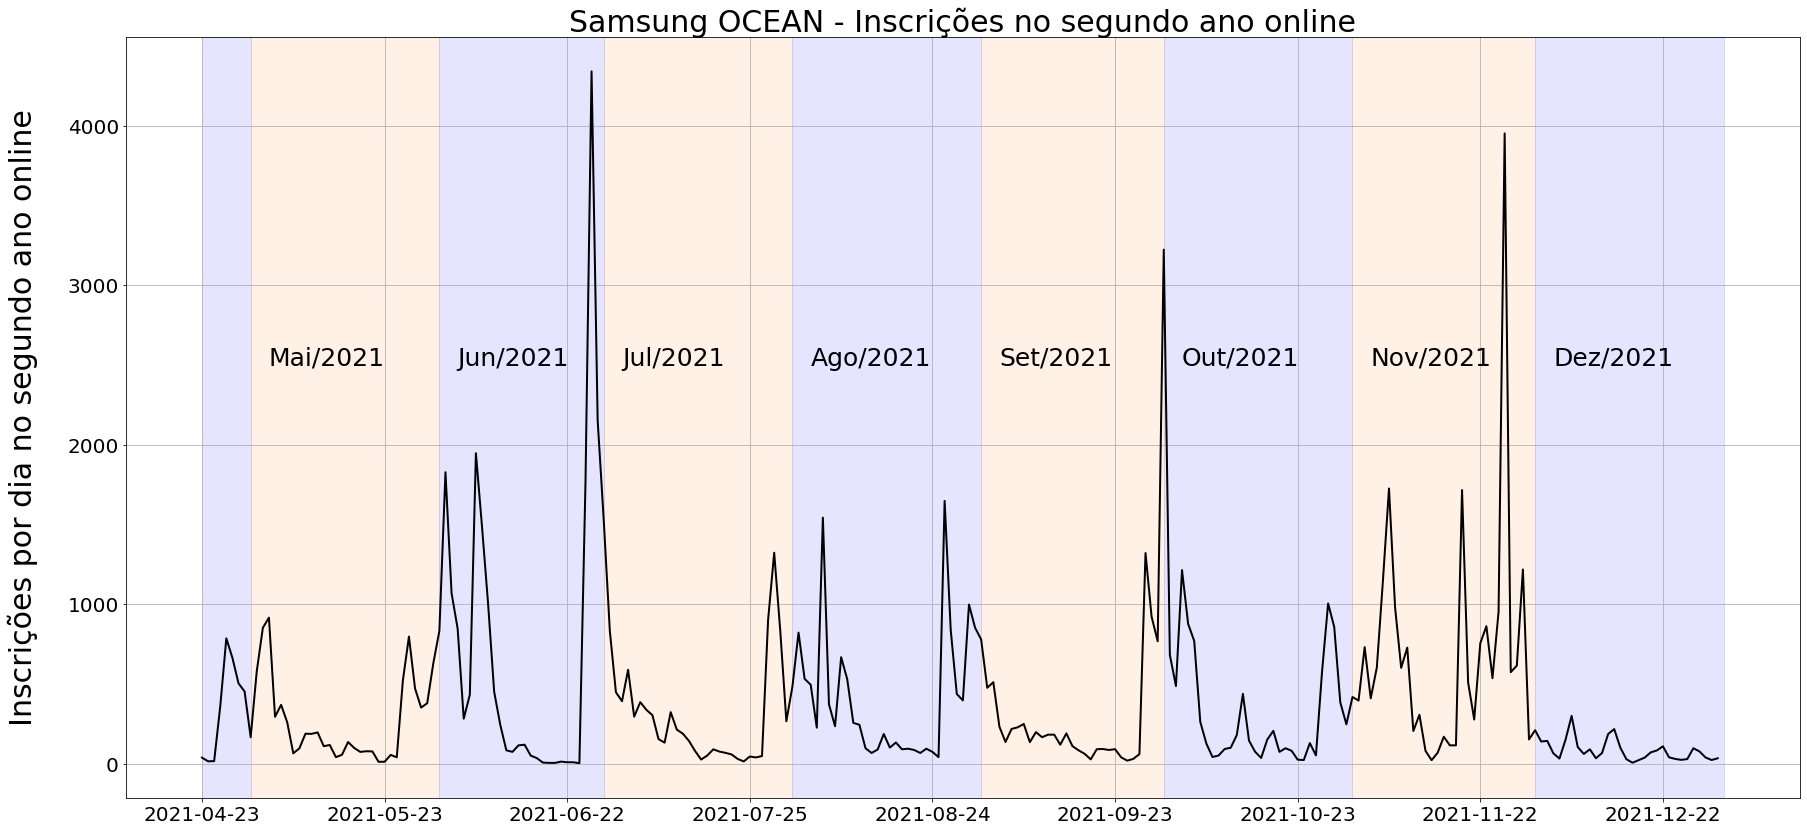

In [12]:
#gráfico número de inscrições por dia 
fig, ax = plt.subplots(figsize=(15*2, 7*2))
plot_per_day, = ax.plot(inscricoes_df_sec_year["data_inscricao"], inscricoes_df_sec_year["inscricoes"], color='black', marker='', linestyle='solid',linewidth=2, markersize=1, label='Novos alunos por dia');

ax.set_title('Samsung OCEAN - Inscrições no segundo ano online', fontsize=30)

plt.grid()
ax.set_ylabel('Inscrições por dia no segundo ano online', fontsize=30)
# ax.set_xlim(xmin=yrs[0], xmax=yrs[-1])

#X_TICKS = 20 # use every nth value; change this number until you like the result
#plt.xticks(range(0, len(dates), X_TICKS), dates[::X_TICKS], rotation = 0)

#ax2 = ax.twinx()  # instantiate a second axes that shares the same x-axis
#plot_accum, = ax2.plot(dates, acumulated, color='blue', marker='', linestyle='solid',linewidth=3, markersize=1, label='Total de alunos cadastrados');

loc = plticker.MultipleLocator(base=30.0) # this locator puts ticks at regular intervals
ax.xaxis.set_major_locator(loc)
#ax2.set_ylabel('Total de alunos cadastrados', fontsize=30, color='blue')


# ax.tick_params(axis='both', which='minor', labelsize=207)

# ax.legend(loc='upper right', fontsize=35)
# ax2.legend(loc='upper left', fontsize=35)


ax.tick_params(labelsize=20)
#ax2.tick_params(labelsize=20, labelcolor = "blue")

ax.yaxis.labelpad = 30
#ax2.yaxis.labelpad = 30


# fill area
color_1 = 'Blue'
color_2 = 'tab:orange'
default_alpha = 0.1

ax.axvspan('2021-04-23', '2021-05-01', alpha=default_alpha, color=color_1)
ax.axvspan('2021-05-01', '2021-06-01', alpha=default_alpha, color=color_2)
ax.axvspan('2021-06-01', '2021-07-01', alpha=default_alpha, color=color_1)
ax.axvspan('2021-07-01', '2021-08-01', alpha=default_alpha, color=color_2)
ax.axvspan('2021-08-01', '2021-09-01', alpha=default_alpha, color=color_1)
ax.axvspan('2021-09-01', '2021-10-01', alpha=default_alpha, color=color_2)
ax.axvspan('2021-10-01', '2021-11-01', alpha=default_alpha, color=color_1)
ax.axvspan('2021-11-01', '2021-12-01', alpha=default_alpha, color=color_2)
ax.axvspan('2021-12-01', '2022-01-01', alpha=default_alpha, color=color_1)

# plt.text('2021-04-02', 5000, r'Abr/2021', fontsize=25)
plt.text('2021-05-04',2500, r'Mai/2021', fontsize=25)
plt.text('2021-06-04',2500, r'Jun/2021', fontsize=25)
plt.text('2021-07-04',2500, r'Jul/2021', fontsize=25)
plt.text('2021-08-04',2500, r'Ago/2021', fontsize=25)
plt.text('2021-09-04',2500, r'Set/2021', fontsize=25)
plt.text('2021-10-04',2500, r'Out/2021', fontsize=25)
plt.text('2021-11-04',2500, r'Nov/2021', fontsize=25)
plt.text('2021-12-04',2500, r'Dez/2021', fontsize=25)

Analise de inscritos

Inscrições de inicio de junho

In [13]:
df_ins_jun_ini = pd.read_sql(r"""
SELECT enrollment.enr_eve_id,event.eve_title,event.eve_start_date as data_inicial,count(*) as soma FROM enrollment
inner join event 
on enr_eve_id = event.eve_id
WHERE DATE_FORMAT(enrollment.enr_creation_date, '%Y-%m-%d') = '2021-06-02'
and event.eve_title not like '%2)'
and event.eve_title not like '%3)'
GROUP BY enr_eve_id 
order by soma desc
""", db_con.mydb)
df_ins_jun_ini

,enr_eve_id,eve_title,data_inicial,soma
0,2355,Introdução a Análise de Dados Geográficos com ...,2021-06-07,113
1,2363,Introdução ao Frontend Web com React (Parte 1),2021-06-15,96
2,2367,"Programando para web com Python, CSS e HTML (P...",2021-06-17,92
3,2354,Oficina: Programação de uma aplicação para Blo...,2021-06-04,86
4,2359,Consultando Bases SQL com Python (Parte 1),2021-06-10,85
5,2378,(Jornada Android) Android: Jetpack e Arquitetura,2021-06-30,70
6,2375,(Jornada Android) Android: Listas com Recycler...,2021-06-25,70
7,2372,(Jornada Android) Android: Laboratório,2021-06-22,70
8,2377,(Jornada Android) Android: Push Notification c...,2021-06-29,70
9,2374,(Jornada Android) Android: Webservices com Ret...,2021-06-24,70


In [14]:
#top 5
df_ins_jun_ini.loc[:5]


,enr_eve_id,eve_title,data_inicial,soma
0,2355,Introdução a Análise de Dados Geográficos com ...,2021-06-07,113
1,2363,Introdução ao Frontend Web com React (Parte 1),2021-06-15,96
2,2367,"Programando para web com Python, CSS e HTML (P...",2021-06-17,92
3,2354,Oficina: Programação de uma aplicação para Blo...,2021-06-04,86
4,2359,Consultando Bases SQL com Python (Parte 1),2021-06-10,85
5,2378,(Jornada Android) Android: Jetpack e Arquitetura,2021-06-30,70


In [15]:
df_ins_jun_ini2 = pd.read_sql(r"""
SELECT enrollment.enr_eve_id,event.eve_title,event.eve_start_date as data_inicial, count(*) as soma FROM enrollment
inner join event 
on enr_eve_id = event.eve_id
WHERE DATE_FORMAT(enrollment.enr_creation_date, '%Y-%m-%d') = '2021-06-07'
and event.eve_title not like '%2)'
and event.eve_title not like '%3)'
GROUP BY enr_eve_id 
order by soma desc
""", db_con.mydb)
df_ins_jun_ini2

,enr_eve_id,eve_title,data_inicial,soma
0,2363,Introdução ao Frontend Web com React (Parte 1),2021-06-15,141
1,2359,Consultando Bases SQL com Python (Parte 1),2021-06-10,139
2,2367,"Programando para web com Python, CSS e HTML (P...",2021-06-17,138
3,2378,(Jornada Android) Android: Jetpack e Arquitetura,2021-06-30,101
4,2375,(Jornada Android) Android: Listas com Recycler...,2021-06-25,101
5,2372,(Jornada Android) Android: Laboratório,2021-06-22,101
6,2377,(Jornada Android) Android: Push Notification c...,2021-06-29,101
7,2374,(Jornada Android) Android: Webservices com Ret...,2021-06-24,101
8,2371,(Jornada Android) Android: Introdução,2021-06-21,101
9,2376,(Jornada Android) Android: Banco de Dados com ...,2021-06-28,101


In [16]:
#top 5
df_ins_jun_ini2.loc[:5]

,enr_eve_id,eve_title,data_inicial,soma
0,2363,Introdução ao Frontend Web com React (Parte 1),2021-06-15,141
1,2359,Consultando Bases SQL com Python (Parte 1),2021-06-10,139
2,2367,"Programando para web com Python, CSS e HTML (P...",2021-06-17,138
3,2378,(Jornada Android) Android: Jetpack e Arquitetura,2021-06-30,101
4,2375,(Jornada Android) Android: Listas com Recycler...,2021-06-25,101
5,2372,(Jornada Android) Android: Laboratório,2021-06-22,101


inscrições de final de junho

In [17]:
df_ins_jun_fim = pd.read_sql(r"""
SELECT enrollment.enr_eve_id,event.eve_title,count(*) as soma FROM enrollment
inner join event 
on enr_eve_id = event.eve_id
WHERE DATE_FORMAT(enrollment.enr_creation_date, '%Y-%m-%d') = '2021-06-29'
and event.eve_title not like '%2)'
and event.eve_title not like '%3)'
GROUP BY enr_eve_id 
order by soma desc
""", db_con.mydb)
df_ins_jun_fim

,enr_eve_id,eve_title,soma
0,2388,Linguagem Python: aprendendo a linguagem (Part...,245
1,2408,Ciência de Dados: Visualização de Dados com Py...,204
2,2391,Introdução ao Deep Learning com Python e Keras...,164
3,2396,Oficina: Design Thinking,158
4,2386,Backend com NodeJs e Express (Parte 1),136
5,2401,Palestra: Introdução ao Blockchain,135
6,2404,Tópicos de UX para IA: Experiências Ominicanal,134
7,2393,Mineração de Opinião com Python,131
8,2394,Desenvolvimento Ágil - DevOps Docker,122
9,2398,Frontend Web com ReactJS: Introdução (Parte 1),122


In [18]:
#top 5
df_ins_jun_fim.loc[:5]


,enr_eve_id,eve_title,soma
0,2388,Linguagem Python: aprendendo a linguagem (Part...,245
1,2408,Ciência de Dados: Visualização de Dados com Py...,204
2,2391,Introdução ao Deep Learning com Python e Keras...,164
3,2396,Oficina: Design Thinking,158
4,2386,Backend com NodeJs e Express (Parte 1),136
5,2401,Palestra: Introdução ao Blockchain,135


inscrições em inicio de outubro

In [19]:
df_ins_out = pd.read_sql(r"""
SELECT enrollment.enr_eve_id,event.eve_title,count(*) as soma FROM enrollment
inner join event 
on enr_eve_id = event.eve_id
WHERE DATE_FORMAT(enrollment.enr_creation_date, '%Y-%m-%d') = '2021-10-01'
and event.eve_title not like '%2)'
and event.eve_title not like '%3)'
GROUP BY enr_eve_id 
order by soma desc
""", db_con.mydb)
df_ins_out

,enr_eve_id,eve_title,soma
0,2588,Android: Laboratório,294
1,2608,Android: Banco de Dados com Android Room,294
2,2596,Android: Webservices com Retrofit e Imagens co...,294
3,2592,Android: GPS com Google Maps,294
4,2635,Android: Jetpack e Arquitetura,294
5,2606,Android: Listas com RecyclerView e Multithread,294
6,2586,Android: Introdução,294
7,2619,Android: Push Notification com Firebase,294
8,2621,Linguagem Python: aprendendo a linguagem (Aula...,62
9,2587,Linguagem Python: aprendendo a linguagem (Part...,62


In [20]:
df_ins_out.loc[:5]

,enr_eve_id,eve_title,soma
0,2588,Android: Laboratório,294
1,2608,Android: Banco de Dados com Android Room,294
2,2596,Android: Webservices com Retrofit e Imagens co...,294
3,2592,Android: GPS com Google Maps,294
4,2635,Android: Jetpack e Arquitetura,294
5,2606,Android: Listas com RecyclerView e Multithread,294


In [21]:
df_ins_out.loc[3].eve_title

'Android: GPS com Google Maps'

inscrições em final de novembro

In [22]:
df_ins_nov = pd.read_sql(r"""
SELECT enrollment.enr_eve_id,event.eve_title,event.eve_start_date as data_inicio,count(*) as soma FROM enrollment
inner join event 
on enr_eve_id = event.eve_id
WHERE DATE_FORMAT(enrollment.enr_creation_date, '%Y-%m-%d') = '2021-11-26'
and event.eve_title not like '%2)'
and event.eve_title not like '%3)'
and event.eve_title not like '%4)'
and event.eve_title not like '%5)'
and event.eve_title not like '%6)'
GROUP BY enr_eve_id 
order by soma desc, data_inicio
""", db_con.mydb)
df_ins_nov

,enr_eve_id,eve_title,data_inicio,soma
0,2725,[FORMAÇÃO MS-DEV] Programação para iniciantes:...,2021-11-29,213
1,2726,[FORMAÇÃO MS-DEV] Aprendendo a programar com C...,2021-11-30,213
2,2732,[FORMAÇÃO MS-DEV] Backend e serviços na nuvem ...,2021-12-08,213
3,2736,[FORMAÇÃO MS-DEV] Plataforma Microsoft e Proje...,2021-12-14,213
4,2770,Android: Laborátorio,2021-12-13,21
5,2769,Android: Introdução,2021-12-13,21
6,2761,Consultando Bases SQL com Python (Parte 1),2021-12-07,20
7,2746,Desenvolvimento Ágil - DevOps Docker,2021-12-01,19
8,2751,Backend com NodeJs e Express (Parte 1),2021-12-06,19
9,2699,Ciência de Dados: Visualização de Dados com Py...,2021-11-29,15


In [23]:
df_ins_nov[:5]

,enr_eve_id,eve_title,data_inicio,soma
0,2725,[FORMAÇÃO MS-DEV] Programação para iniciantes:...,2021-11-29,213
1,2726,[FORMAÇÃO MS-DEV] Aprendendo a programar com C...,2021-11-30,213
2,2732,[FORMAÇÃO MS-DEV] Backend e serviços na nuvem ...,2021-12-08,213
3,2736,[FORMAÇÃO MS-DEV] Plataforma Microsoft e Proje...,2021-12-14,213
4,2770,Android: Laborátorio,2021-12-13,21


In [24]:
df_ins_nov.loc[4].eve_title

'Android: Laborátorio'

In [25]:
#get total before 
# male
sql = r"""
SELECT DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') as data, COUNT(*) as quantidade
FROM student s, samsungstudents
WHERE s.stu_id=samsungstudents.sam_stu_id AND s.stu_gender="M"
AND DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') BETWEEN '1970-04-23' AND '2021-04-22'
"""

db_con = OceanDB()
df = pd.read_sql(sql, db_con.mydb)
total_before_male = df['quantidade'].iloc[0]

# female
sql = r"""
SELECT DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') as data, COUNT(*) as quantidade
FROM student s, samsungstudents
WHERE s.stu_id=samsungstudents.sam_stu_id AND s.stu_gender="F"
AND DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') BETWEEN '1970-04-23' AND '2021-04-22'
"""

db_con = OceanDB()
df = pd.read_sql(sql, db_con.mydb)
total_before_female = df['quantidade'].iloc[0]


# data of second year 
db_con = OceanDB()
cursor = db_con.getCursor()

# FEMALE
cursor.execute(r"""
SELECT DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') as data, COUNT(*) as quantidade
FROM student s, samsungstudents
WHERE s.stu_id=samsungstudents.sam_stu_id AND s.stu_gender="F"
AND DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') BETWEEN '2021-04-23' AND '2021-12-31'
GROUP BY DAY(samsungstudents.created_at), MONTH(samsungstudents.created_at), YEAR(samsungstudents.created_at) 
ORDER BY data
""")

result = cursor.fetchall()

dates_female = []
quantities_female = []

for x in result:
  dates_female.append(x[0])
  quantities_female.append(x[1])
  # print(x)

print(len(dates_female))
print(len(quantities_female))

# print(dates_female)
# print(quantities_female)


# MALE
cursor.execute(r"""
SELECT DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') as data, COUNT(*) as quantidade
FROM student s, samsungstudents
WHERE s.stu_id=samsungstudents.sam_stu_id AND s.stu_gender="M"
AND DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') BETWEEN '2021-04-23' AND '2021-12-31'
GROUP BY DAY(samsungstudents.created_at), MONTH(samsungstudents.created_at), YEAR(samsungstudents.created_at) 
ORDER BY data
""")

result = cursor.fetchall()

dates_male = []
quantities_male = []

for x in result:
    dates_male.append(x[0])
    quantities_male.append(x[1])
    # print(x)

print(len(dates_male))
print(len(quantities_male))

243
243
249
249


In [26]:
# Merge dates for male and female

for i,d in enumerate(dates_male):
    if d not in dates_female:
        dates_female.insert(i, d)
        quantities_female.insert(i, 0)
        

# Merge dates for male and female

for i,d in enumerate(dates_female):
    if d not in dates_male:
        dates_male.insert(i, d)
        quantities_male.insert(i, 0)

# sort the female list
zipped_lists = zip(dates_female, quantities_female)
sorted_pairs = sorted(zipped_lists, key=lambda d: d[0])
tuples = zip(*sorted_pairs)
dates_female, quantities_female = [ list(tuple) for tuple in tuples]

# sort the male list
zipped_lists = zip(dates_male, quantities_male)
sorted_pairs = sorted(zipped_lists, key=lambda d: d[0])
tuples = zip(*sorted_pairs)
dates_male, quantities_male = [ list(tuple) for tuple in tuples]

# get acuumulated distributions
acumulated_female = np.cumsum(quantities_female)+total_before_female
acumulated_male = np.cumsum(quantities_male)+total_before_male

In [27]:
print(len(dates_female))
print(len(quantities_female))
print(len(dates_male))
print(len(quantities_male))

251
251
251
251


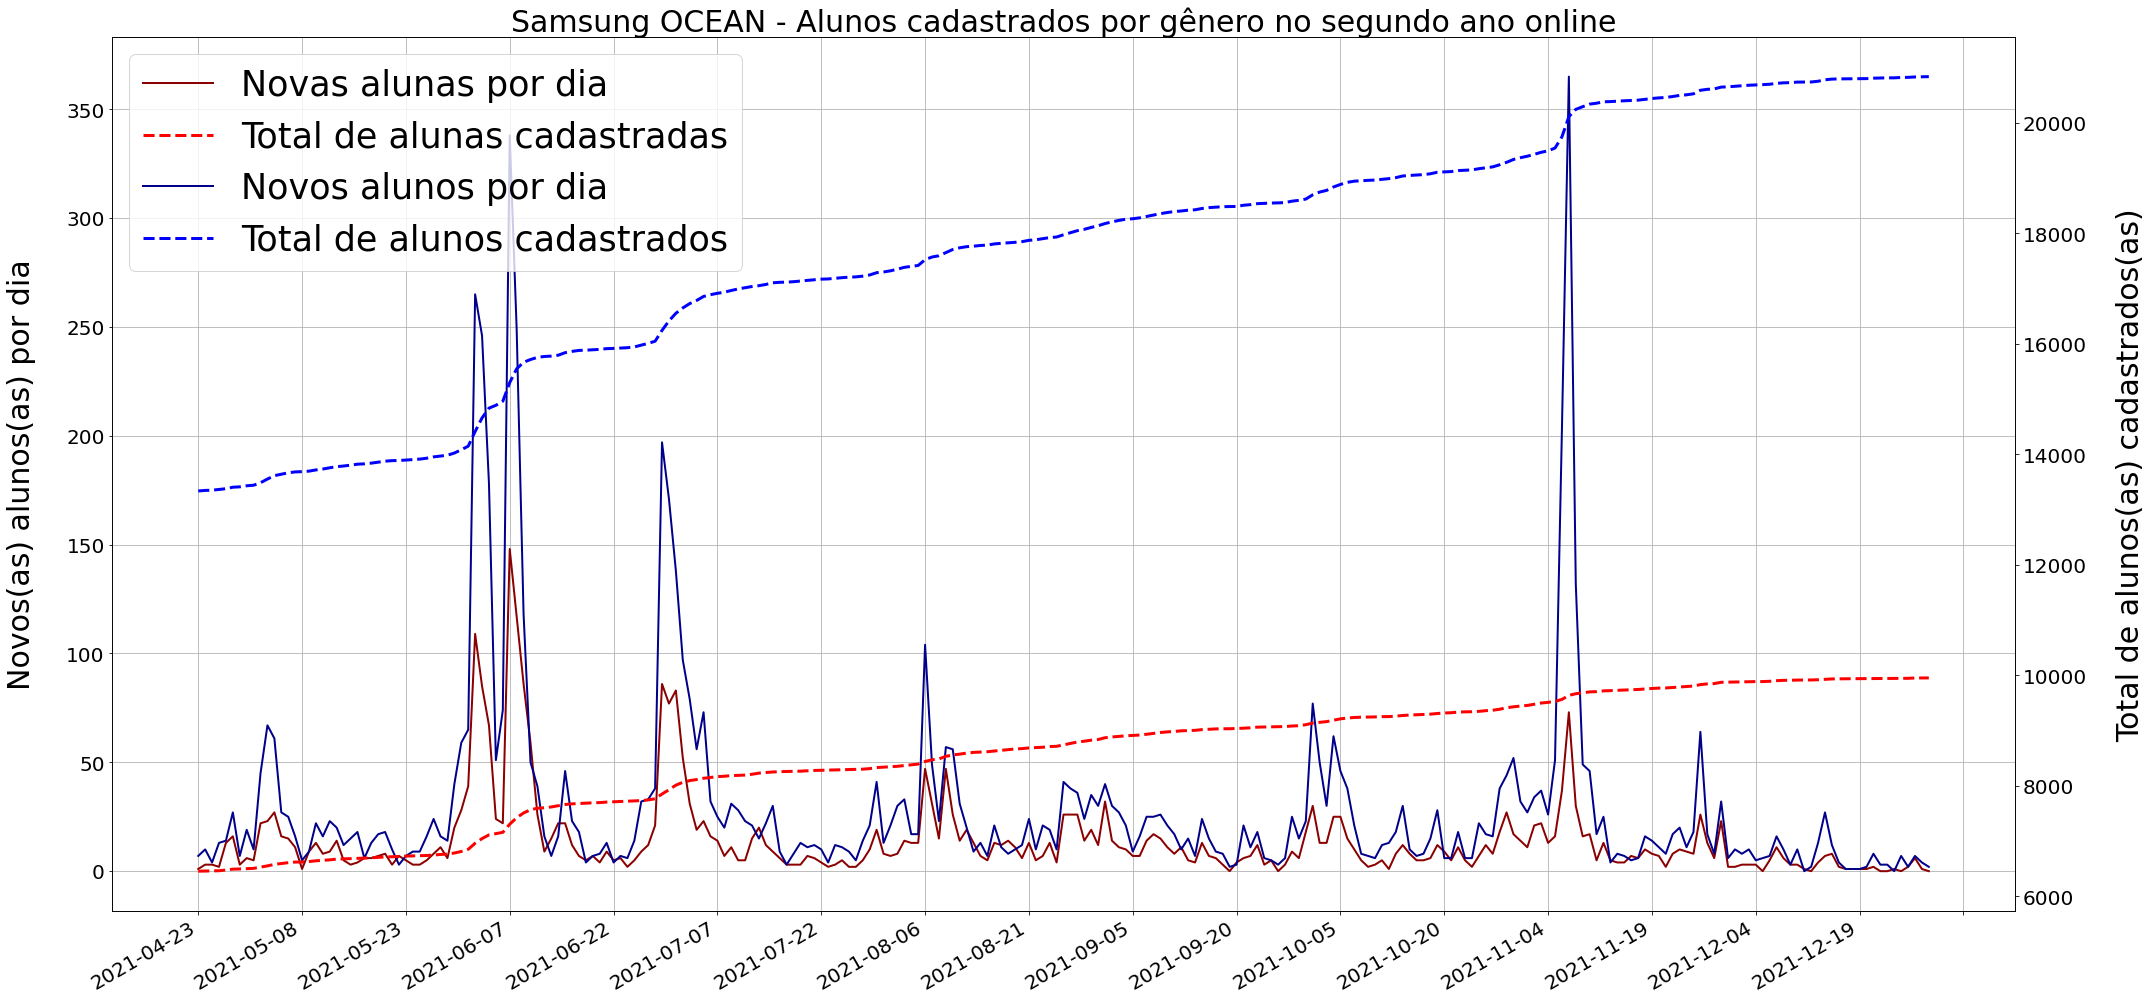

In [28]:
fig, ax = plt.subplots(figsize=(15*2, 7*2))
plot_per_day_female, = ax.plot(dates_female, quantities_female, color='darkred', marker='', linestyle='solid',linewidth=2, markersize=1, label='Novas alunas por dia');
plot_per_day_male, = ax.plot(dates_male, quantities_male, color='darkblue', marker='', linestyle='solid',linewidth=2, markersize=1, label='Novos alunos por dia');

ax.set_title('Samsung OCEAN - Alunos cadastrados por gênero no segundo ano online', fontsize=30)

plt.grid()
ax.set_ylabel('Novos(as) alunos(as) por dia', fontsize=30)
# ax.set_xlim(xmin=yrs[0], xmax=yrs[-1])

# X_TICKS = 20 # use every nth value; change this number until you like the result
# plt.xticks(range(0, len(dates), X_TICKS), dates[::X_TICKS], rotation = 70)

ax2 = ax.twinx()  # instantiate a second axes that shares the same x-axis
plot_accum_female, = ax2.plot(dates_female, acumulated_female, color='red', marker='', linestyle='dashed',linewidth=3, markersize=1, label='Total de alunas cadastradas');
plot_accum_male, = ax2.plot(dates_female, acumulated_male, color='blue', marker='', linestyle='dashed',linewidth=3, markersize=1, label='Total de alunos cadastrados');

loc = plticker.MultipleLocator(base=15.0) # this locator puts ticks at regular intervals
ax2.xaxis.set_major_locator(loc)
ax2.set_ylabel('Total de alunos(as) cadastrados(as)', fontsize=30, color='black')


# ax.tick_params(axis='both', which='minor', labelsize=207)

# ax.legend(loc='upper right', fontsize=35)
# ax2.legend(loc='upper left', fontsize=35)


ax.tick_params(labelsize=20)
ax2.tick_params(labelsize=20, labelcolor = "black")

ax.yaxis.labelpad = 30
ax2.yaxis.labelpad = 30

# ax3 = ax.twinx()  # instantiate a third axes that shares the same x-axis
# plot_moving_mean = ax3.fill_between(dates_female, media_movel, color='red', label=f'Média móvel ({time_window} dias)');
# plot_moving_mean.set_alpha(0.15)
# ax3.xaxis.set_major_locator(loc)
# ax3.set_ylabel('Média móvel', fontsize=30, color='red')
# ax3.tick_params(labelsize=20, labelcolor = "red")
# ax3.yaxis.labelpad = 15
# ax3.spines['right'].set_position(('outward', 200))
# ax3.spines['right'].set_color('red')
# # plt.fill_between(x, y)



lns = [plot_per_day_female, plot_accum_female, plot_per_day_male, plot_accum_male]
labs = [l.get_label() for l in lns]
# labs.append(plot_moving_mean.get_label())
# print(labs)
ax.legend([plot_per_day_female, plot_accum_female, plot_per_day_male, plot_accum_male], labs, loc='upper left', fontsize=35)


fig.autofmt_xdate()
fig.tight_layout()

In [29]:
cpf_region = {}

cpf_region['Norte'] = r"(SUBSTR(s.stu_cpf, 9, 1) = '2')"
cpf_region['Sul'] = r"(SUBSTR(s.stu_cpf, 9, 1) = '0' OR SUBSTR(s.stu_cpf, 9, 1) = '9')"
cpf_region['Sudeste'] = r"(SUBSTR(s.stu_cpf, 9, 1) = '6' OR SUBSTR(s.stu_cpf, 9, 1) = '7' OR SUBSTR(s.stu_cpf, 9, 1) = '8')"
cpf_region['Centro-Oeste'] = r"(SUBSTR(s.stu_cpf, 9, 1) = '1')"
cpf_region['Nordeste'] = r"(SUBSTR(s.stu_cpf, 9, 1) = '3' OR SUBSTR(s.stu_cpf, 9, 1) = '4' OR SUBSTR(s.stu_cpf, 9, 1) = '5')"

In [30]:
total_before = {}

for r in cpf_region:
    print(f"---> {r}")
    sql = r"""
    SELECT DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') as data, COUNT(*) as quantidade
    FROM student s, samsungstudents
    WHERE s.stu_id=samsungstudents.sam_stu_id
    AND """ + cpf_region[r] + """ 
    AND DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') BETWEEN '1970-04-23' AND '2021-04-22'
    """

    db_con = OceanDB()
    df = pd.read_sql(sql, db_con.mydb)
    total_before[r] = df['quantidade'].iloc[0]


total_before

---> Norte
---> Sul
---> Sudeste
---> Centro-Oeste
---> Nordeste


{'Norte': 7934,
 'Sul': 1054,
 'Sudeste': 8091,
 'Centro-Oeste': 759,
 'Nordeste': 1943}

In [31]:
students_per_region = {}

for r in cpf_region:
    print(f"---> {r}")
    sql = r"""
    SELECT DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') as data, COUNT(*) as quantidade_""" + slugify(r) + """
    FROM student s, samsungstudents
    WHERE s.stu_id=samsungstudents.sam_stu_id
    AND """ + cpf_region[r] + """ 
    AND DATE_FORMAT(samsungstudents.created_at, '%Y-%m-%d') BETWEEN '2021-04-23' AND '2021-12-31'
    GROUP BY DAY(samsungstudents.created_at), MONTH(samsungstudents.created_at), YEAR(samsungstudents.created_at) 
    ORDER BY data
    """

    db_con = OceanDB()
    df = pd.read_sql(sql, db_con.mydb)
    students_per_region[r] = df.set_index("data")


# print(students_per_region)

# concatenate DFs

students_per_region = pd.concat([students_per_region[r] for r in students_per_region], axis=1).fillna(0)
students_per_region

---> Norte
---> Sul
---> Sudeste
---> Centro-Oeste
---> Nordeste


,quantidade_norte,quantidade_sul,quantidade_sudeste,quantidade_centro_oeste,quantidade_nordeste
data,,,,,
2021-04-23,3.0,0.0,4.0,1.0,0.0
2021-04-24,1.0,0.0,8.0,2.0,2.0
2021-04-25,1.0,0.0,2.0,1.0,3.0
2021-04-26,2.0,3.0,5.0,0.0,5.0
2021-04-27,12.0,0.0,11.0,1.0,3.0
...,...,...,...,...,...
2021-12-12,0.0,0.0,2.0,0.0,0.0
2021-12-17,0.0,0.0,1.0,0.0,1.0
2021-12-23,0.0,0.0,2.0,1.0,0.0


In [32]:
# get accummated distributions and dates
acummulated_per_region = {}
for r in cpf_region:
    acummulated_per_region[r] = np.cumsum(students_per_region['quantidade_' + slugify(r)].values)+total_before[r]

dates = students_per_region.index.values


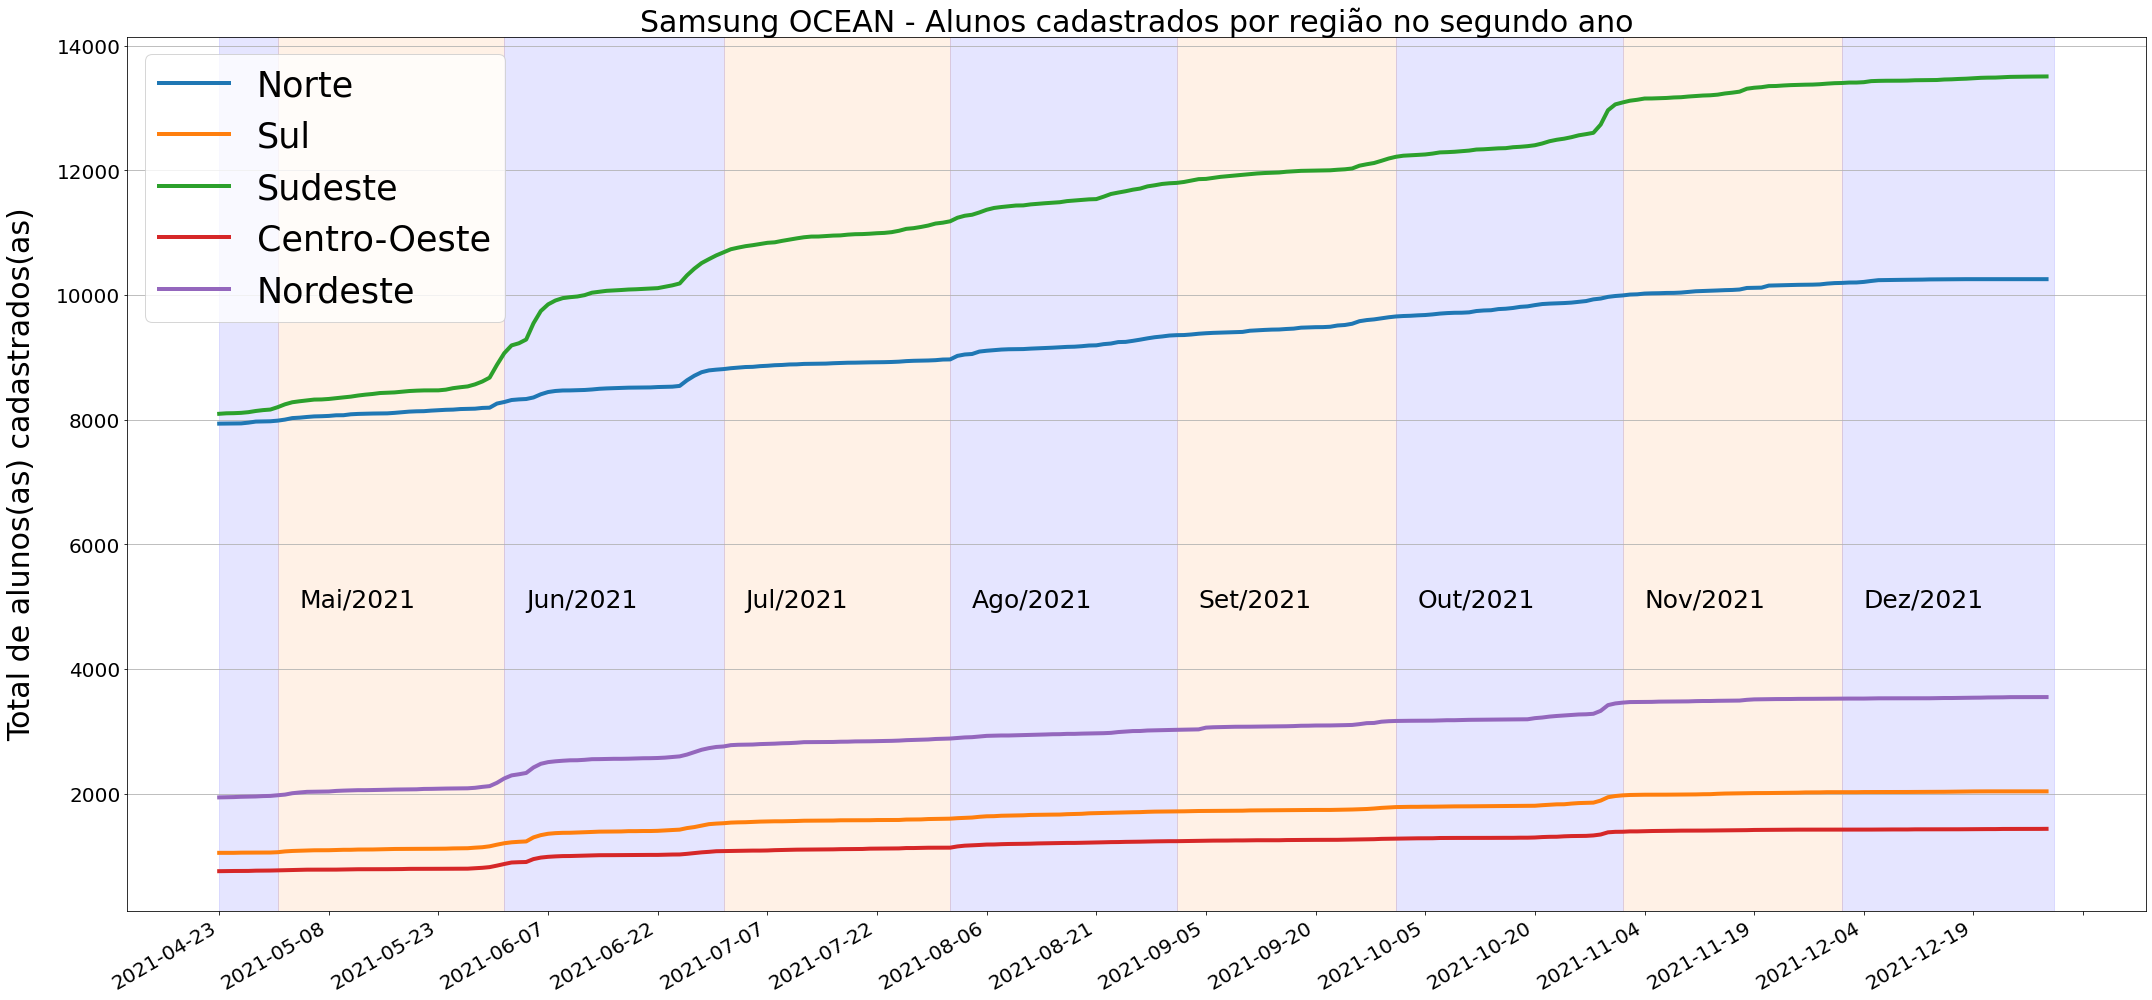

In [33]:
fig, ax = plt.subplots(figsize=(15*2, 7*2))

plots_per_region = {}
for r in cpf_region:
    plots_per_region[r], = ax.plot(sorted(dates), acummulated_per_region[r], marker='', linestyle='solid',linewidth=4, markersize=1, label=r);

ax.set_title('Samsung OCEAN - Alunos cadastrados por região no segundo ano', fontsize=30)

ax.yaxis.grid()

ax.set_ylabel('Novos(as) alunos(as) por região', fontsize=30)
# ax.set_xlim(xmin=yrs[0], xmax=yrs[-1])

#X_TICKS = 20 # use every nth value; change this number until you like the result
#plt.xticks(range(0, len(dates), X_TICKS), dates[::X_TICKS], rotation = 0)


loc = plticker.MultipleLocator(base=15.0) # this locator puts ticks at regular intervals
ax.xaxis.set_major_locator(loc)
ax.set_ylabel('Total de alunos(as) cadastrados(as)', fontsize=30, color='black')

ax.legend(loc='upper left', fontsize=35)

ax.tick_params(labelsize=20)
ax.yaxis.labelpad = 20

# fill area
color_1 = 'Blue'
color_2 = 'tab:orange'
default_alpha = 0.1

ax.axvspan('2021-04-23', '2021-05-01', alpha=default_alpha, color=color_1)
ax.axvspan('2021-05-01', '2021-06-01', alpha=default_alpha, color=color_2)
ax.axvspan('2021-06-01', '2021-07-01', alpha=default_alpha, color=color_1)
ax.axvspan('2021-07-01', '2021-08-01', alpha=default_alpha, color=color_2)
ax.axvspan('2021-08-01', '2021-09-01', alpha=default_alpha, color=color_1)
ax.axvspan('2021-09-01', '2021-10-01', alpha=default_alpha, color=color_2)
ax.axvspan('2021-10-01', '2021-11-01', alpha=default_alpha, color=color_1)
ax.axvspan('2021-11-01', '2021-12-01', alpha=default_alpha, color=color_2)
ax.axvspan('2021-12-01', '2022-01-01', alpha=default_alpha, color=color_1)


# plt.text('2021-04-02', 5000, r'Abr/2021', fontsize=25)
plt.text('2021-05-04', 5000, r'Mai/2021', fontsize=25)
plt.text('2021-06-04', 5000, r'Jun/2021', fontsize=25)
plt.text('2021-07-04', 5000, r'Jul/2021', fontsize=25)
plt.text('2021-08-04', 5000, r'Ago/2021', fontsize=25)
plt.text('2021-09-04', 5000, r'Set/2021', fontsize=25)
plt.text('2021-10-04', 5000, r'Out/2021', fontsize=25)
plt.text('2021-11-04', 5000, r'Nov/2021', fontsize=25)
plt.text('2021-12-04', 5000, r'Dez/2021', fontsize=25)

# plt.text('2021-04-04', 5000, r'Abr/2021', fontsize=25)



fig.autofmt_xdate()
fig.tight_layout()

#fig.savefig("ocean_numero_de_alunos_regiao.pdf")
#fig.savefig("ocean_numero_de_alunos_regiao.png")



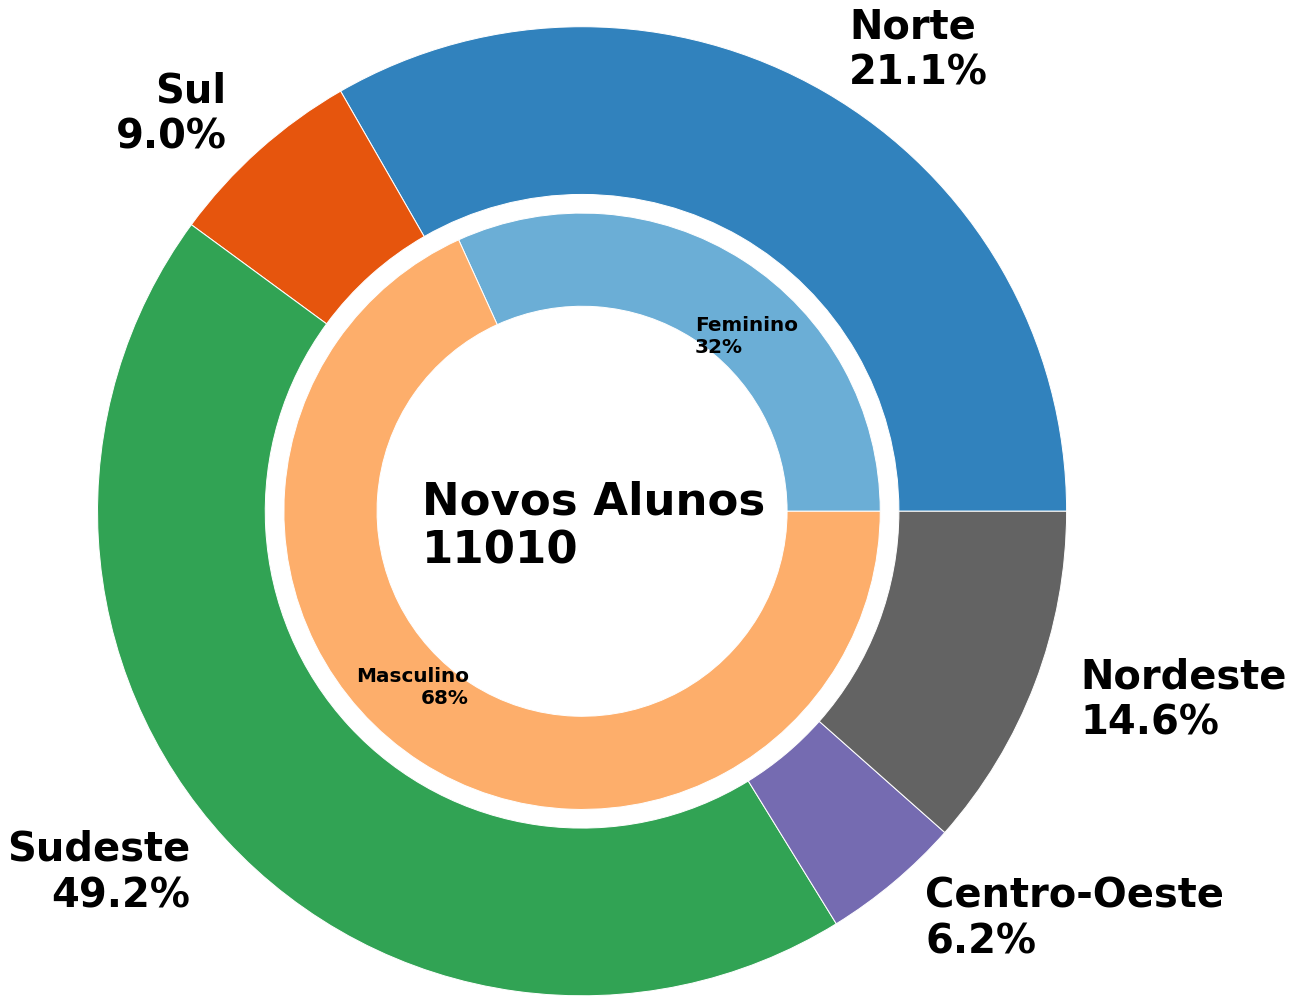

In [34]:
fig, ax = plt.subplots(figsize=(15*2, 7*2))

size = 0.45

vals = []
labels = []
percent = r'10%'
total_new_students = acumulated[-1]-total_before_male-total_before_female
# print(total_new_students)
# print(acummulated_per_region['Norte'][-1]-total_before['Norte'])
for r in cpf_region:
    labels.append(f"{r}\n{round((acummulated_per_region[r][-1]-total_before[r])/total_new_students*100, 1)}%")
    vals.append(acummulated_per_region[r][-1])


cmap = plt.get_cmap("tab20c")
outer_colors = cmap(np.arange(5)*4)
inner_colors = cmap([1,6])

ax.pie(vals, radius=1.3, colors=outer_colors,
       wedgeprops=dict(width=size, edgecolor='w'), labels = labels, labeldistance = 1.1,
                                  textprops=dict(color="black", fontsize=40, fontweight='bold'))


labels_gender = [
        f"Feminino\n{round((acumulated_female[-1]-total_before_female)/total_new_students*100)}%", 
        f"Masculino\n{round((acumulated_male[-1]-total_before_male)/total_new_students*100)}%", 
        ]

ax.pie([acumulated_female[-1]-total_before_female, acumulated_male[-1]-total_before_male], labels = labels_gender, radius=1-size+0.25, colors=inner_colors, wedgeprops=dict(width=size-0.2, edgecolor='w'), textprops=dict(color="black", fontsize=20, fontweight='bold'), labeldistance = 0.7)

# ax.legend()

# ax.set_title('Samsung OCEAN - Novos Alunos', fontsize=30)
ax.text(-0.43, -0.04, f'Novos Alunos\n{total_new_students}', fontsize=45, fontweight='bold', verticalalignment='center',color="black");

fig.tight_layout();
fig.savefig("pizza_alunos_regiao_segundo_ano.png")


In [35]:
#quantitativo de vagas, inscrições e certificados 
df_analise = pd.read_csv("cursos_ofertados_2_ano_com_trilha.csv")
df_analise.columns


C:\Users\Talissa\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (20) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


Index(['Unnamed: 0', 'eve_id', 'eve_title', 'eve_vacancy', 'eve_workload',
       'eve_start_date', 'eve_end_date', 'eve_start_hour', 'eve_end_hour',
       'eve_enrollment_start', 'eve_enrollment_end', 'eve_speaker_name',
       'eve_audience', 'eve_requirements', 'eve_creation_date',
       'fre_enr_stu_id', 'fre_cla_id', 'fre_status', 'stu_session', 'stu_name',
       'stu_cpf', 'stu_phone', 'stu_gender', 'stu_birth_date',
       'stu_creation_date', 'stu_last_login', 'stu_email', 'course_name',
       'eve_trilha', 'is_session'],
      dtype='object')

In [36]:
#procurando os cursos da iot week para remoção do consolidado
def search_word(df,search_column,palavra):
    new_df = df.loc[df[search_column].str.contains(palavra,flags=re.IGNORECASE)]
    return new_df

In [37]:
df_iotweek = search_word(df_analise,"course_name",'iotweek')
df_iotweek

,Unnamed: 0,eve_id,eve_title,eve_vacancy,eve_workload,eve_start_date,eve_end_date,eve_start_hour,eve_end_hour,eve_enrollment_start,...,stu_cpf,stu_phone,stu_gender,stu_birth_date,stu_creation_date,stu_last_login,stu_email,course_name,eve_trilha,is_session
71989,87064,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,70862028272,92982295408,M,2016-04-13,2022-01-19 03:53:54,NaN,jayultonn_arianos@hotmail.com,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
71990,87065,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,29926988814,11960567494,F,1980-11-28,2021-12-20 15:30:52,NaN,emtakata2016@hotmail.com,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
71991,87066,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,9509354686,31988518245,M,1987-12-23,2021-12-15 11:29:25,NaN,danielpldm8701@hotmail.com,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
71992,87067,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,52792617268,92993523078,M,1986-11-05,2021-12-20 15:30:51,NaN,charlie.nielsen@yahoo.com.br,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
71993,87068,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,62085441220,92994205286,M,1979-03-10,2021-12-20 15:30:51,2019-05-17 15:45:22,doca.ac@gmail.com,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72559,87634,2759,[IOT WEEK] WORKSHOP: IoT em Nuvem com node-red,200,03:00,2021-12-16,2021-12-16,14:00,17:15,2021-11-24,...,3668528500,71988408516,M,1989-10-09,2021-12-20 15:30:58,2021-12-14 19:56:51,ueslei.brito@ufba.br,[iotweek]workshop:iotemnuvemcomnode-red,IOT,-
72560,87635,2759,[IOT WEEK] WORKSHOP: IoT em Nuvem com node-red,200,03:00,2021-12-16,2021-12-16,14:00,17:15,2021-11-24,...,4123979270,92994787996,M,2002-11-10,2021-12-17 15:15:43,2021-12-15 16:37:22,marcelogds2002@gmail.com,[iotweek]workshop:iotemnuvemcomnode-red,IOT,-
72561,87636,2759,[IOT WEEK] WORKSHOP: IoT em Nuvem com node-red,200,03:00,2021-12-16,2021-12-16,14:00,17:15,2021-11-24,...,39122082808,11989662676,M,1991-05-15,2021-12-17 15:10:12,2021-12-15 19:59:17,audioslave.sp@gmail.com,[iotweek]workshop:iotemnuvemcomnode-red,IOT,-
72562,87637,2759,[IOT WEEK] WORKSHOP: IoT em Nuvem com node-red,200,03:00,2021-12-16,2021-12-16,14:00,17:15,2021-11-24,...,44678534806,11953089008,M,1996-05-15,2021-12-17 15:01:03,2021-12-16 00:48:49,paulo.tonidandel@gmail.com,[iotweek]workshop:iotemnuvemcomnode-red,IOT,-


In [38]:
#removendo dados da iot week 
df_analise.drop(df_iotweek.index,inplace=True)

In [39]:
#quantidade de vagas por trilha 
df_analise_vagas_trilha = df_analise[(df_analise.is_session=="-") | (df_analise.is_session=="1")]
df_analise_vagas_trilha

,Unnamed: 0,eve_id,eve_title,eve_vacancy,eve_workload,eve_start_date,eve_end_date,eve_start_hour,eve_end_hour,eve_enrollment_start,...,stu_cpf,stu_phone,stu_gender,stu_birth_date,stu_creation_date,stu_last_login,stu_email,course_name,eve_trilha,is_session
0,0,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
1,1,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,38533792816,11984061040,M,1991-08-26,2021-10-01 01:31:45,NaN,aguiar.rafaelm@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
2,2,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,89609034268,92991015108,M,1986-05-16,2021-05-14 00:14:44,NaN,anglops@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
3,3,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,00289630240,92991551517,M,1989-11-09,2021-08-17 23:45:03,NaN,gerson.cunha@outlook.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
4,4,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,01603746269,92984041284,M,1997-08-21,2021-05-10 20:30:46,2019-02-20 08:02:28,gqs.snf17@uea.edu.br,tizen:ferramentaeambientededesenvolvimento,TZN,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73407,88583,2770,Android: Laborátorio,600,03:00,2021-12-13,2021-12-13,14:00,17:00,1970-01-01,...,70326324240,92991598464,F,2000-09-14,2021-12-14 03:23:44,2021-12-10 16:54:18,remacielsantos@gmail.com,android:laborátorio,AND,-
73408,88584,2770,Android: Laborátorio,600,03:00,2021-12-13,2021-12-13,14:00,17:00,1970-01-01,...,5419082276,97984029973,M,1998-05-21,2021-12-14 03:23:44,2021-12-10 18:25:53,matheusmc210598@gmail.com,android:laborátorio,AND,-
73409,88585,2770,Android: Laborátorio,600,03:00,2021-12-13,2021-12-13,14:00,17:00,1970-01-01,...,1633608204,92999026351,M,1998-08-03,2021-12-20 15:30:53,2021-12-10 20:41:28,jeancarlosfr91@gmail.com,android:laborátorio,AND,-
73410,88586,2770,Android: Laborátorio,600,03:00,2021-12-13,2021-12-13,14:00,17:00,1970-01-01,...,70135747244,92992396519,M,2003-01-28,2021-12-15 11:29:26,2021-12-13 01:21:26,gabriel992396519@gmail.com,android:laborátorio,AND,-


In [40]:
df_analise_vagas_trilha = df_analise_vagas_trilha.drop_duplicates(["course_name","eve_start_date"],ignore_index=True)
df_analise_vagas_trilha

,Unnamed: 0,eve_id,eve_title,eve_vacancy,eve_workload,eve_start_date,eve_end_date,eve_start_hour,eve_end_hour,eve_enrollment_start,...,stu_cpf,stu_phone,stu_gender,stu_birth_date,stu_creation_date,stu_last_login,stu_email,course_name,eve_trilha,is_session
0,0,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
1,229,2297,Introdução a Análise de Dados Geográficos com ...,500,03:00,2021-04-29,2021-04-29,19:00,22:00,2021-03-19,...,02409289541,11959056292,F,1986-10-11,2021-04-30 19:11:01,2019-04-09 23:10:55,oliveira.naiane@hotmail.com,introduçãoaanálisededadosgeográficoscompython,IAR,-
2,609,2298,Tizen: Desenvolvimento de aplicação para ambie...,500,02:00,2021-04-30,2021-04-30,17:00,19:00,2021-03-19,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,tizen:desenvolvimentodeaplicaçãoparaambientetizen,TZN,-
3,837,2302,Introdução à Internet das Coisas,500,03:00,2021-04-27,2021-04-27,14:00,17:00,2021-04-09,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,introduçãoàinternetdascoisas,IOT,-
4,1021,2303,Laboratório de IoT com Arduino,500,03:00,2021-04-27,2021-04-27,18:00,21:00,2021-04-09,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,laboratóriodeiotcomarduino,IOT,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,86995,2754,Ciência de Dados: Fundamentos de Análise de Da...,600,03:00,2021-12-06,2021-12-06,18:00,21:00,2021-11-24,...,3768571297,92994312710,M,1997-11-27,2021-12-07 13:59:58,2018-09-27 17:30:00,andrecoelhoassante@gmail.com,ciênciadedados:fundamentosdeanálisededadoscomo...,IAR,-
156,87639,2761,Consultando Bases SQL com Python (Parte 1),600,03:00,2021-12-07,2021-12-07,09:00,12:00,2021-11-24,...,23030426823,11951610815,M,1989-03-20,2022-01-19 03:53:55,NaN,arnaldo_viana@yahoo.com.br,consultandobasessqlcompython(parte1),PRG,1
157,88045,2766,Introdução a Internet das Coisas,500,02:00,2021-12-09,2021-12-09,19:00,21:00,2021-11-24,...,56222394272,92984710111,F,1975-02-24,2021-12-17 15:20:54,2019-05-17 08:23:48,kakathelima@hotmail.com,introduçãoainternetdascoisas,IOT,-
158,88252,2769,Android: Introdução,600,03:00,2021-12-13,2021-12-13,09:00,12:00,2021-11-24,...,52588955215,92981726129,F,1983-03-11,2021-12-14 03:23:38,NaN,dskt_cardoso@hotmail.com,android:introdução,AND,-


In [41]:
df_analise_vagas_trilha.course_name.unique()

array(['tizen:ferramentaeambientededesenvolvimento',
       'introduçãoaanálisededadosgeográficoscompython',
       'tizen:desenvolvimentodeaplicaçãoparaambientetizen',
       'introduçãoàinternetdascoisas', 'laboratóriodeiotcomarduino',
       'programandoparawebcompython,cssehtml(parte1)',
       'desenvolvimentoágil-devopsdocker',
       'desenvolvimentoágil:devopsgit',
       'introduçãoaobackendcomnodejseexpress',
       'laboratóriodeiotcomraspberrypi',
       'laboratóriodebackendcomnodejseexpress',
       'linguagempython:aprendendoalinguagem(parte1)',
       'introduçãoaofrontendwebcomreact',
       'introduçãoaodeeplearningcompythonekeras(parte1)',
       'palestra:assistentevirtualdevozembixby-trazendointeligênciaàinterface',
       'integrandoosserviçosdebackendnanuvem',
       'laboratóriodefrontendwebcomreact', 'mineraçãodeopiniãocompython',
       'android:introdução', 'android:laboratório',
       'webscrapingcompython(parte1)', 'introduçãoaoblockchain',
       'ciência

In [42]:
#total de vagas por trilha
qtde_vagas_trilha = df_analise_vagas_trilha.groupby("eve_trilha")["eve_vacancy"].sum()
qtde_vagas_trilha

eve_trilha
AND       12800
BCKEND    10860
BLC        5000
BXB        3200
FABLAB       15
FRTEND     3600
GME        4205
IAR       14200
IOT       10445
PRG        9030
TZN        2200
WRB        1500
ÁGIL       6420
Name: eve_vacancy, dtype: int64

In [43]:
#quantidade de inscritos por trilha
df_inscritos_trilha = df_analise[(df_analise.is_session=="-") | (df_analise.is_session=="1")]
df_inscritos_trilha.shape

(47524, 30)

In [44]:
qtde_inscritos_trilha = df_inscritos_trilha.groupby(["eve_trilha"]).eve_start_date.size()
qtde_inscritos_trilha

eve_trilha
AND       11115
BCKEND     4965
BLC        2834
BXB         709
FABLAB       17
FRTEND     2257
GME        1644
IAR        8989
IOT        4990
PRG        6408
TZN         661
WRB         442
ÁGIL       2493
Name: eve_start_date, dtype: int64

In [45]:
#quantidade de certificados 
df_certificados_trilha = df_analise[df_analise.fre_status=="Presente"]
df_certificados_trilha.shape

(18660, 30)

In [46]:
qtde_certificados_trilha = df_certificados_trilha.groupby(["eve_trilha"]).eve_start_date.size()
qtde_certificados_trilha

eve_trilha
AND       2009
BCKEND    2114
BLC        693
BXB        196
FABLAB      66
FRTEND    1220
GME       1619
IAR       4206
IOT       1263
PRG       4221
TZN        123
WRB        119
ÁGIL       811
Name: eve_start_date, dtype: int64

In [47]:
#organizando as informações em tabela 
df_alunos_trilha = pd.DataFrame(data={"qtde_vagas_trilha":qtde_vagas_trilha.values,
"qtde_inscritos_trilha":qtde_inscritos_trilha.values,"qtde_certificados_trilha":qtde_certificados_trilha.values,"eve_trilha":qtde_vagas_trilha.index})
df_alunos_trilha

,qtde_vagas_trilha,qtde_inscritos_trilha,qtde_certificados_trilha,eve_trilha
0,12800,11115,2009,AND
1,10860,4965,2114,BCKEND
2,5000,2834,693,BLC
3,3200,709,196,BXB
4,15,17,66,FABLAB
5,3600,2257,1220,FRTEND
6,4205,1644,1619,GME
7,14200,8989,4206,IAR
8,10445,4990,1263,IOT
9,9030,6408,4221,PRG


Como queremos analisar apenas os cursos online, FABLAB será removido

In [48]:
df_alunos_trilha = df_alunos_trilha.loc[df_alunos_trilha.loc[:,"eve_trilha"]!="FABLAB"]
df_alunos_trilha

,qtde_vagas_trilha,qtde_inscritos_trilha,qtde_certificados_trilha,eve_trilha
0,12800,11115,2009,AND
1,10860,4965,2114,BCKEND
2,5000,2834,693,BLC
3,3200,709,196,BXB
5,3600,2257,1220,FRTEND
6,4205,1644,1619,GME
7,14200,8989,4206,IAR
8,10445,4990,1263,IOT
9,9030,6408,4221,PRG
10,2200,661,123,TZN


In [49]:
trilhas_nome_completo = {"IAR":"Inteligência Artificial/DS","BXB":"Bixby","IOT":"IOT","TZN":"Tizen","BLC":"Blockchain",
           "GME":"Games","LAB":"Lab","NGC":"Negócios","RVA":"Realidade Virtual","TALK":"Talk",
           "PRG":"Programação","AND":"Android","OUTROS":"Outros","INT":"Intensivo","FRTEND":"Front-end","WRB":"Wearbles","BCKEND":"Back-end","ÁGIL":"Desenvolvimento Ágil"}

df_alunos_trilha["eve_trilha_completo"] = [trilhas_nome_completo[trilha] for trilha in df_alunos_trilha.eve_trilha]

<ipython-input-49-19b3176eb7ad>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_alunos_trilha["eve_trilha_completo"] = [trilhas_nome_completo[trilha] for trilha in df_alunos_trilha.eve_trilha]


In [50]:
df_alunos_trilha

,qtde_vagas_trilha,qtde_inscritos_trilha,qtde_certificados_trilha,eve_trilha,eve_trilha_completo
0,12800,11115,2009,AND,Android
1,10860,4965,2114,BCKEND,Back-end
2,5000,2834,693,BLC,Blockchain
3,3200,709,196,BXB,Bixby
5,3600,2257,1220,FRTEND,Front-end
6,4205,1644,1619,GME,Games
7,14200,8989,4206,IAR,Inteligência Artificial/DS
8,10445,4990,1263,IOT,IOT
9,9030,6408,4221,PRG,Programação
10,2200,661,123,TZN,Tizen


In [51]:
#definindo função para formatar valores de float para gráfico 
#valores maiores que 1000 ficaram 1.2k por exemplo e valores menores ficaram da mesma forma sem formatação
def format_float_number(number):
  result = number/1000
  if result >= 1:
    i = number//1000
    f = number%1000
    if f==0:
      final_result = i
      return f"{final_result}K"
    else:
        f = f/1000
        f = round(f,1)
        final_result = i+f
        return f"{final_result}K"
  else:
     final_result=number
     return f"{final_result}"

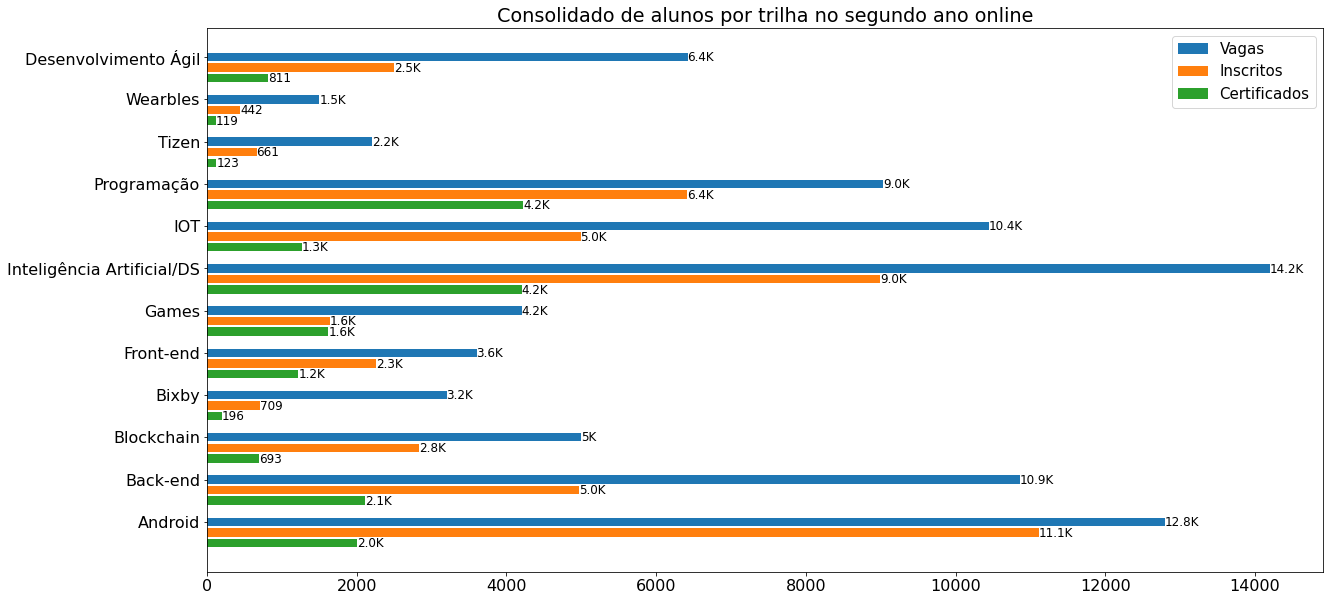

In [91]:
y = np.arange(1,46,4)
y2 = np.arange(2,47,4)
y3 = np.arange(3,48,4)

fig,ax = plt.subplots(1,1,figsize=(20,10))

ax1=ax.barh(y3,df_alunos_trilha["qtde_vagas_trilha"],tick_label=df_alunos_trilha["eve_trilha_completo"])
ax2=ax.barh(y2,df_alunos_trilha["qtde_inscritos_trilha"])
ax3=ax.barh(y,df_alunos_trilha["qtde_certificados_trilha"])


#realizando anotações 
###para vagas por trilha
for data in ax1.get_children():
    x1 = data.get_width()
    y1 = data.get_y()
    ax.annotate(text=format_float_number(x1),xy=(x1,y1),fontsize=12)
    
###para inscrições por trilha
for data in ax2.get_children():
    x2 = data.get_width()
    y2 = data.get_y()
    ax.annotate(text=format_float_number(x2),xy=(x2,y2),fontsize=12)
    
###para certificados por trilha
for data in ax3.get_children():
    x3 = data.get_width()
    y3 = data.get_y()
    ax.annotate(text=format_float_number(x3),xy=(x3,y3),fontsize=12)


ax.set_title("Consolidado de alunos por trilha no segundo ano online")
ax.legend(labels=["Vagas","Inscritos","Certificados"],loc="best",fontsize=15)

#config plot params 
mpl.rcParams["font.size"]=16
mpl.rcParams["font.family"]="monospace"
mpl.rcParams["font.monospace"]="Andale Mono"

In [37]:
#tabela de adesão 

df_adesao = pd.DataFrame(index=df_alunos_trilha.eve_trilha_completo.values,data={"Vagas":df_alunos_trilha.qtde_vagas_trilha.values,
"Inscritos":df_alunos_trilha.qtde_inscritos_trilha.values,
"Certificados":df_alunos_trilha.qtde_certificados_trilha.values,
"Adesão":(df_alunos_trilha.qtde_certificados_trilha.values/df_alunos_trilha.qtde_inscritos_trilha.values)*100})

#modificando os valores de adesao para duas casas decimais 
df_adesao.Adesão = [round(number,2) for number in df_adesao.Adesão]

df_adesao

,Vagas,Inscritos,Certificados,Adesão
Android,12800,11115,2009,18.07
Back-end,10860,4965,2114,42.58
Blockchain,5000,2834,693,24.45
Bixby,3200,709,196,27.64
Front-end,3600,2257,1220,54.05
Games,4205,1644,1619,98.48
Inteligência Artificial/DS,14200,8989,4206,46.79
IOT,10445,4990,1263,25.31
Programação,9030,6408,4221,65.87
Tizen,2200,661,123,18.61
